In [1]:
from models.base_model import TimeSeriesRegressionModel
from utils.data import CMAPSSDataset

In [3]:
data = CMAPSSDataset(clip_rul=False).load()

In [4]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [5]:
NOMINAL_OPERATING_CONDITIONS = pd.DataFrame(
    {
        "operational_setting_1": [0, 10, 20, 25, 35, 42],
        "operational_setting_2": [0.00, 0.25, 0.70, 0.62, 0.84, 0.84],
        "operational_setting_3": [100, 100, 100, 60, 100, 100]
    },
    index=[1, 2, 3, 4, 5, 6]
)

In [6]:
data_copy = data.copy()



data_copy["setting_1_round"] = data_copy["setting_1"].round(0)
data_copy["setting_2_round"] = data_copy["setting_2"].round(2)
data_copy["setting_3_round"] = data_copy["setting_3"].round(0)

In [7]:
data_copy.head()

,unit_number,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_18,sensor_19,sensor_20,sensor_21,dataset,RUL,unique_motor_id,setting_1_round,setting_2_round,setting_3_round
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388,100.0,39.06,23.4190,FD001,191,FD001_1,-0.0,-0.0,100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388,100.0,39.00,23.4236,FD001,190,FD001_1,0.0,-0.0,100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388,100.0,38.95,23.3442,FD001,189,FD001_1,-0.0,0.0,100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388,100.0,38.88,23.3739,FD001,188,FD001_1,0.0,0.0,100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388,100.0,38.90,23.4044,FD001,187,FD001_1,-0.0,-0.0,100.0


In [8]:
rounded_columns = [
    "setting_1_round",
    "setting_2_round",
    "setting_3_round"
]

for column in rounded_columns:
    data_copy.loc[data_copy[column] == 0, column] = 0.0

data_copy["operating_condition"] = (
    data_copy["setting_1_round"].astype(str)
    + "_"
    + data_copy["setting_2_round"].astype(str)
    + "_"
    + data_copy["setting_3_round"].astype(str)
)

In [9]:
data_copy.head()

,unit_number,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_19,sensor_20,sensor_21,dataset,RUL,unique_motor_id,setting_1_round,setting_2_round,setting_3_round,operating_condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,100.0,39.06,23.4190,FD001,191,FD001_1,0.0,0.0,100.0,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,100.0,39.00,23.4236,FD001,190,FD001_1,0.0,0.0,100.0,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,100.0,38.95,23.3442,FD001,189,FD001_1,0.0,0.0,100.0,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,100.0,38.88,23.3739,FD001,188,FD001_1,0.0,0.0,100.0,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,100.0,38.90,23.4044,FD001,187,FD001_1,0.0,0.0,100.0,0.0_0.0_100.0


In [10]:
data_copy["setting_1_round"] = data_copy["setting_1"].round(0)
data_copy["setting_3_round"] = data_copy["setting_3"].round(0)

setting_2_values = [0.00, 0.25, 0.62, 0.70, 0.84]

data_copy["setting_2_round"] = data_copy["setting_2"].apply(
    lambda value: min(
        setting_2_values,
        key=lambda nominal: abs(value - nominal)
    )
)

In [11]:
data_copy.head()

,unit_number,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_19,sensor_20,sensor_21,dataset,RUL,unique_motor_id,setting_1_round,setting_2_round,setting_3_round,operating_condition
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,100.0,39.06,23.4190,FD001,191,FD001_1,-0.0,0.0,100.0,0.0_0.0_100.0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,100.0,39.00,23.4236,FD001,190,FD001_1,0.0,0.0,100.0,0.0_0.0_100.0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,100.0,38.95,23.3442,FD001,189,FD001_1,-0.0,0.0,100.0,0.0_0.0_100.0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,100.0,38.88,23.3739,FD001,188,FD001_1,0.0,0.0,100.0,0.0_0.0_100.0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,100.0,38.90,23.4044,FD001,187,FD001_1,-0.0,0.0,100.0,0.0_0.0_100.0


In [12]:
data_copy["operating_condition"].unique()

array(['0.0_0.0_100.0', '35.0_0.84_100.0', '42.0_0.84_100.0',
       '25.0_0.62_60.0', '20.0_0.7_100.0', '10.0_0.25_100.0'],
      dtype=object)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# Original, unrounded setting columns
setting_columns = [
    "setting_1",
    "setting_2",
    "setting_3"
]


def cluster_and_plot(
    data,
    dataset_name,
    n_clusters
):
    """
    Filter one dataset, cluster its original operating settings,
    and plot the clusters in three dimensions.
    """

    # 1. Filter FD001 or FD002 from the combined DataFrame
    df = data.loc[
        data["dataset"] == dataset_name
    ].copy()

    if df.empty:
        raise ValueError(
            f"No rows found for dataset {dataset_name}"
        )

    # 2. Keep rows with valid original setting values
    df = df.dropna(
        subset=setting_columns
    ).copy()

    # 3. Standardize the original settings
    # Needed because the three columns have different scales
    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(
        df[setting_columns]
    )

    # 4. Apply K-Means
    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42,
        n_init=10
    )

    df["cluster"] = (
        kmeans.fit_predict(X_scaled) + 1
    )

    # 5. Convert cluster centres back to original units
    cluster_centres = scaler.inverse_transform(
        kmeans.cluster_centers_
    )

    cluster_centres_df = pd.DataFrame(
        cluster_centres,
        columns=setting_columns
    )

    cluster_centres_df["cluster"] = range(
        1,
        n_clusters + 1
    )

    cluster_centres_df = cluster_centres_df[
        [
            "cluster",
            "setting_1",
            "setting_2",
            "setting_3"
        ]
    ]

    print(f"{dataset_name} cluster centres:")
    display(cluster_centres_df.round(4))

    # 6. Create the 3D graph
    fig = plt.figure(figsize=(10, 8))

    ax = fig.add_subplot(
        111,
        projection="3d"
    )

    scatter = ax.scatter(
        df["setting_1"],
        df["setting_2"],
        df["setting_3"],
        c=df["cluster"],
        s=10,
        alpha=0.35
    )

    # Plot the K-Means centres
    ax.scatter(
        cluster_centres[:, 0],
        cluster_centres[:, 1],
        cluster_centres[:, 2],
        marker="X",
        s=250,
        edgecolors="black",
        linewidths=1.5,
        label="Cluster centre"
    )

    ax.set_xlabel("Setting 1")
    ax.set_ylabel("Setting 2")
    ax.set_zlabel("Setting 3")

    ax.set_title(
        f"{dataset_name}: {n_clusters} operating-condition cluster(s)"
    )

    ax.legend()

    fig.colorbar(
        scatter,
        ax=ax,
        label="Cluster number",
        shrink=0.7
    )

    plt.tight_layout()
    plt.show()

    return df, cluster_centres_df

FD001 cluster centres:


,cluster,setting_1,setting_2,setting_3
0,1,-0.0,0.0,100.0


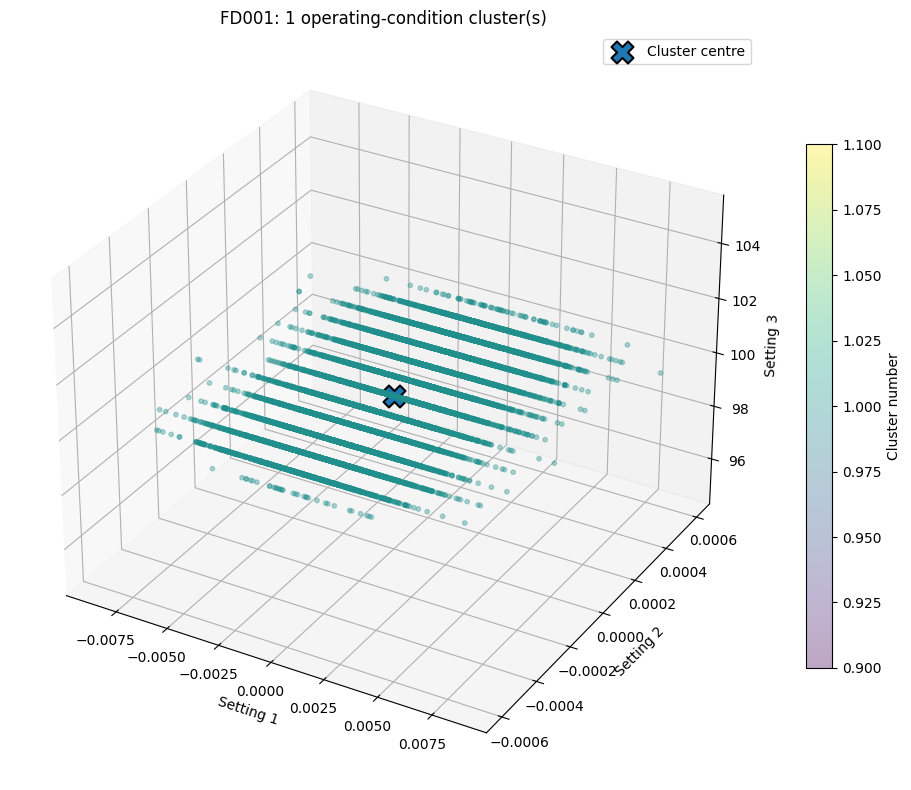

In [14]:
fd001_clustered, fd001_centres = cluster_and_plot(
    data=data_copy,
    dataset_name="FD001",
    n_clusters=1
)

FD002 cluster centres:


,cluster,setting_1,setting_2,setting_3
0,1,42.0030,0.8405,100.0
1,2,0.0015,0.0005,100.0
2,3,20.0030,0.7005,100.0
3,4,25.0030,0.6205,60.0
4,5,10.0030,0.2505,100.0
5,6,35.0030,0.8405,100.0


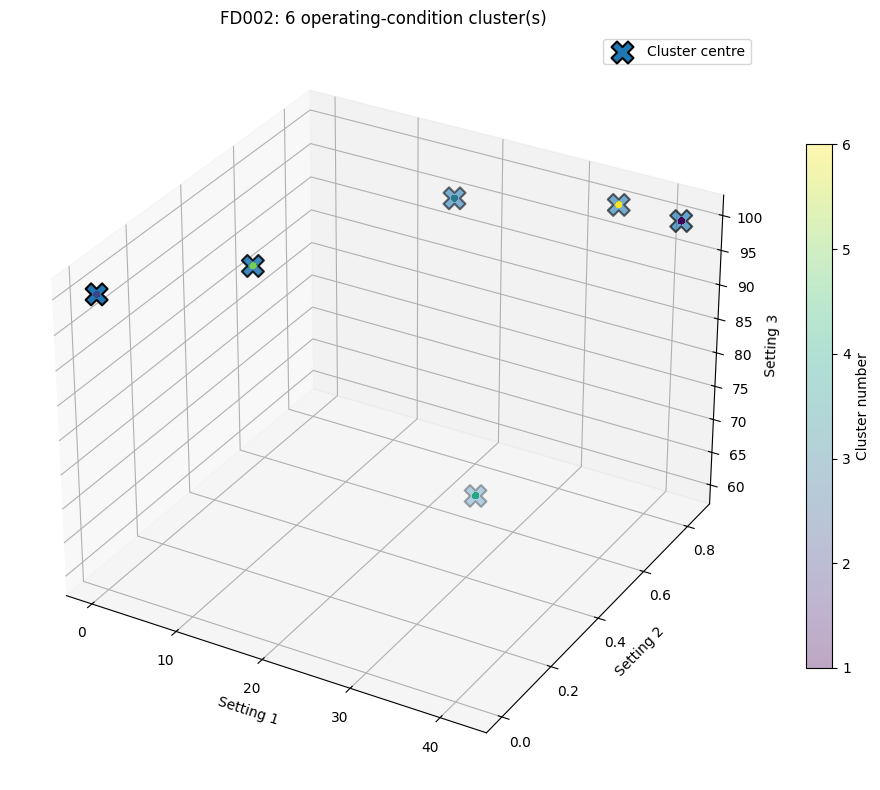

In [15]:
fd002_clustered, fd002_centres = cluster_and_plot(
    data=data_copy,
    dataset_name="FD002",
    n_clusters=6
)

In [16]:
fd002_centres_sorted = (
    fd002_centres
    .sort_values("setting_1")
    .reset_index(drop=True)
)

fd002_centres_sorted["condition"] = range(1, 7)

display(
    fd002_centres_sorted[
        [
            "condition",
            "setting_1",
            "setting_2",
            "setting_3"
        ]
    ].round(4)
)

,condition,setting_1,setting_2,setting_3
0,1,0.0015,0.0005,100.0
1,2,10.0030,0.2505,100.0
2,3,20.0030,0.7005,100.0
3,4,25.0030,0.6205,60.0
4,5,35.0030,0.8405,100.0
5,6,42.0030,0.8405,100.0


In [19]:
data_copy.head()

,unit_number,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,unique_motor_id,setting_1_round,setting_2_round,setting_3_round,operating_condition_0.0_0.0_100.0,operating_condition_10.0_0.25_100.0,operating_condition_20.0_0.7_100.0,operating_condition_25.0_0.62_60.0,operating_condition_35.0_0.84_100.0,operating_condition_42.0_0.84_100.0
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,FD001_1,-0.0,0.0,100.0,1,0,0,0,0,0
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,FD001_1,0.0,0.0,100.0,1,0,0,0,0,0
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,FD001_1,-0.0,0.0,100.0,1,0,0,0,0,0
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,FD001_1,0.0,0.0,100.0,1,0,0,0,0,0
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,FD001_1,-0.0,0.0,100.0,1,0,0,0,0,0


In [17]:
import pandas as pd

# One-hot encode the operating_condition column
data_copy = pd.get_dummies(
    data_copy,
    columns=["operating_condition"],
    prefix="operating_condition",
    dtype=int
)

# Check the newly created columns
operating_condition_columns = [
    col for col in data_copy.columns
    if col.startswith("operating_condition_")
]

print(operating_condition_columns)
print(data_copy[operating_condition_columns].head())

['operating_condition_0.0_0.0_100.0', 'operating_condition_10.0_0.25_100.0', 'operating_condition_20.0_0.7_100.0', 'operating_condition_25.0_0.62_60.0', 'operating_condition_35.0_0.84_100.0', 'operating_condition_42.0_0.84_100.0']
   operating_condition_0.0_0.0_100.0  operating_condition_10.0_0.25_100.0  \
0                                  1                                    0   
1                                  1                                    0   
2                                  1                                    0   
3                                  1                                    0   
4                                  1                                    0   

   operating_condition_20.0_0.7_100.0  operating_condition_25.0_0.62_60.0  \
0                                   0                                   0   
1                                   0                                   0   
2                                   0                                   0  

In [18]:
operating_condition_encoded = pd.get_dummies(
    data_copy["operating_condition"],
    prefix="operating_condition",
    dtype=int
)

data_copy = pd.concat(
    [data_copy, operating_condition_encoded],
    axis=1
)

print(data_copy.head())

KeyError: 'operating_condition'